# Creating Dataset

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from PIL import Image
from PIL import ImageFilter
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from google.colab import drive
drive.mount('/content/drive')

# Check if GPU use is available
print(torch.cuda.is_available())

# Determine the device to use
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA device.")
else:
    device = torch.device("cpu")
    print("Using CPU device.")

Mounted at /content/drive
True
Using CUDA device.


In [2]:
# Train Transformations class
class ImageTransformationsTrain(Dataset):

    # Initialization method
    def __init__(self, imageFolder):
        self.imageFolder = imageFolder

    # Length function
    def __len__(self):
        return len(self.imageFolder)

    # Image transformations in __getitem__ function
    def __getitem__(self, index):

        # Convert to tensor function
        convertToTensor = transforms.ToTensor()

        # Image list of tensors
        imageList = []

        # Get image and label
        image, label = self.imageFolder[index]

        # Append image to list
        imageList.append(convertToTensor(image))

        # BLUR
        imageList.append(convertToTensor(image.filter(ImageFilter.BLUR)))

        # CONTOUR
        # imageList.append(convertToTensor(image.filter(ImageFilter.CONTOUR)))

        # DETAIL
        # imageList.append(convertToTensor(image.filter(ImageFilter.DETAIL)))

        # EDGE_ENHANCE
        # imageList.append(convertToTensor(image.filter(ImageFilter.EDGE_ENHANCE)))

        # EDGE_ENHANCE_MORE
        # imageList.append(convertToTensor(image.filter(ImageFilter.EDGE_ENHANCE_MORE)))

        # Emboss
        # imageList.append(convertToTensor(np.array(image.filter(ImageFilter.EMBOSS))))

        # GaussianBlur
        imageList.append(convertToTensor(image.filter(ImageFilter.GaussianBlur)))

        # MaxFilter
        # imageList.append(convertToTensor(image.filter(ImageFilter.MaxFilter)))

        # MedianFilter
        imageList.append(convertToTensor(image.filter(ImageFilter.MedianFilter)))

        # MinFilter
        # imageList.append(convertToTensor(image.filter(ImageFilter.MinFilter)))

        # ModeFilter
        imageList.append(convertToTensor(image.filter(ImageFilter.ModeFilter)))

        # SMOOTH
        # imageList.append(convertToTensor(image.filter(ImageFilter.SMOOTH)))

        # SMOOTH_MORE
        imageList.append(convertToTensor(image.filter(ImageFilter.SMOOTH_MORE)))

        # SHARPEN
        imageList.append(convertToTensor(image.filter(ImageFilter.SHARPEN)))

        # UnsharpMask
        imageList.append(convertToTensor(image.filter(ImageFilter.UnsharpMask)))

        # Mirror image
        # imageList.append(convertToTensor(image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)))
        # flippedImage = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

        # BLUR
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.BLUR)))

        # CONTOUR
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.CONTOUR)))

        # DETAIL
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.DETAIL)))

        # EDGE_ENHANCE
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.EDGE_ENHANCE)))

        # EDGE_ENHANCE_MORE
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.EDGE_ENHANCE_MORE)))

        # GaussianBlur
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.GaussianBlur)))

        # MaxFilter
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.MaxFilter)))

        # MedianFilter
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.MedianFilter)))

        # MinFilter
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.MinFilter)))

        # ModeFilter
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.ModeFilter)))

        # SMOOTH
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.SMOOTH)))

        # SMOOTH_MORE
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.SMOOTH_MORE)))

        # SHARPEN
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.SHARPEN)))

        # UnsharpMask
        # imageList.append(convertToTensor(flippedImage.filter(ImageFilter.UnsharpMask)))

        # Cropping image (cropping song into numberOfCrops parts)
        widthImage, heightImage = image.size
        numberOfCrops = 3
        cropWidth = (widthImage / numberOfCrops) - 1
        for j in range(numberOfCrops):
            croppingArea = (j * cropWidth, 0, (j + 1) * cropWidth, heightImage - 1)
            temporaryCroppedImage = image.crop(croppingArea).resize((widthImage, heightImage))
            # temporaryFlippedCroppedImage = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT).crop(croppingArea).resize((widthImage, heightImage))
            imageList.append(convertToTensor(temporaryCroppedImage))
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage))

            # Cropped image
            # BLUR
            imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.BLUR)))

            # CONTOUR
            # imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.CONTOUR)))

            # DETAIL
            # imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.DETAIL)))

            # EDGE_ENHANCE
            # imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.EDGE_ENHANCE)))

            # EDGE_ENHANCE_MORE
            # imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.EDGE_ENHANCE_MORE)))

            # GaussianBlur
            imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.GaussianBlur)))

            # MaxFilter
            # imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.MaxFilter)))

            # MedianFilter
            imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.MedianFilter)))

            # MinFilter
            # imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.MinFilter)))

            # ModeFilter
            imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.ModeFilter)))

            # SMOOTH
            # imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.SMOOTH)))

            # SMOOTH_MORE
            imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.SMOOTH_MORE)))

            # SHARPEN
            imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.SHARPEN)))

            # UnsharpMask
            imageList.append(convertToTensor(temporaryCroppedImage.filter(ImageFilter.UnsharpMask)))

            # Flipped and Cropped image
            # BLUR
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.BLUR)))

            # CONTOUR
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.CONTOUR)))

            # DETAIL
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.DETAIL)))

            # EDGE_ENHANCE
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.EDGE_ENHANCE)))

            # EDGE_ENHANCE_MORE
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.EDGE_ENHANCE_MORE)))

            # GaussianBlur
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.GaussianBlur)))

            # MaxFilter
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.MaxFilter)))

            # MedianFilter
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.MedianFilter)))

            # MinFilter
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.MinFilter)))

            # ModeFilter
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.ModeFilter)))

            # SMOOTH
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.SMOOTH)))

            # SMOOTH_MORE
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.SMOOTH_MORE)))

            # SHARPEN
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.SHARPEN)))

            # UnsharpMask
            # imageList.append(convertToTensor(temporaryFlippedCroppedImage.filter(ImageFilter.UnsharpMask)))

        return torch.stack(imageList), label

# Validation and Test Transformations class
class ImageTransformationsValidationAndTest(Dataset):

    # Initialization method
    def __init__(self, imageFolder):
        self.imageFolder = imageFolder

    # Length function
    def __len__(self):
        return len(self.imageFolder)

    # Image transformation in __getitem__ function
    def __getitem__(self, index):

        # Convert to tensor function
        convertToTensor = transforms.ToTensor()

        # Image list of tensors
        imageList = []

        # Get image and label
        image, label = self.imageFolder[index]

        # Append image to list
        imageList.append(convertToTensor(image))

        return torch.stack(imageList), label

# Get images efficiently
imageDirectory =  'drive/MyDrive/images_original'

# Create image folder and get textual labels
imageFolder = datasets.ImageFolder(root = imageDirectory, transform = None)
classNames = imageFolder.classes
classRange = range(len(classNames))
zippedClassRangeAndNames = zip(classRange, classNames)
classDictionary = dict(zippedClassRangeAndNames)

# Split the dataset into training, validation, and testing sets
trainSize = int(0.7 * len(imageFolder))
validationSize = int(0.15 * len(imageFolder))
testSize = len(imageFolder) - trainSize - validationSize

# Splitting dataset
seedValue = 42
trainDataset, validationDataset, testDataset = random_split(imageFolder, [trainSize, validationSize, testSize], generator=torch.Generator().manual_seed(seedValue))

# Transformations
trainImageTransformations = ImageTransformationsTrain(trainDataset)
validationImageTransformations = ImageTransformationsValidationAndTest(validationDataset)
testImageTransformations = ImageTransformationsValidationAndTest(testDataset)

# Create data loaders
batchSize = 64
dataLoaderTrain = DataLoader(trainImageTransformations, batch_size = batchSize, shuffle = True)
dataLoaderValidation = DataLoader(validationImageTransformations, batch_size = batchSize, shuffle = True)
dataLoaderTest = DataLoader(testImageTransformations, batch_size = batchSize, shuffle = True)

Train
for training epoch number  1 , the loss is  73.68260750613669  and the accuracy is  0.10206545064377683
for epoch number  1 , the loss is  2.3025849537561403  and the accuracy is  0.10738255033557047
for training epoch number  2 , the loss is  73.68266129391388  and the accuracy is  0.08695457796852647
for epoch number  2 , the loss is  2.3025849537561403  and the accuracy is  0.10738255033557047
for training epoch number  3 , the loss is  73.68269272832912  and the accuracy is  0.10108190271816882
for epoch number  3 , the loss is  2.3025849537561403  and the accuracy is  0.10738255033557047
for training epoch number  4 , the loss is  73.6826857429035  and the accuracy is  0.1052843347639485
for epoch number  4 , the loss is  2.3025849537561403  and the accuracy is  0.10738255033557047
for training epoch number  5 , the loss is  73.68267736039277  and the accuracy is  0.10881616595135908
for epoch number  5 , the loss is  2.3025849537561403  and the accuracy is  0.10738255033557

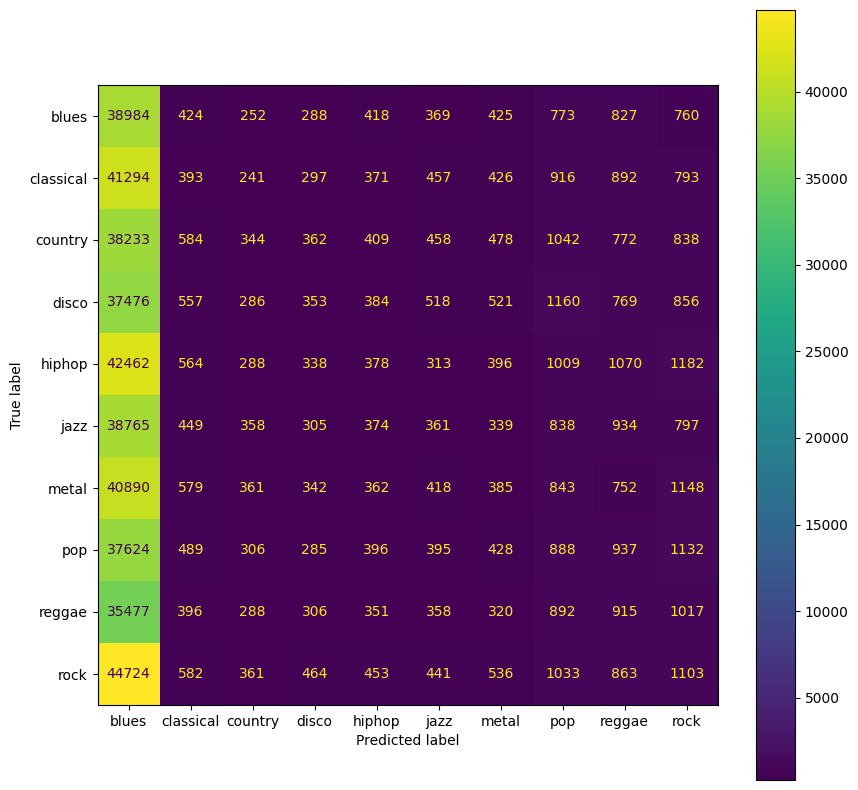



Validation confusion matrix plot:


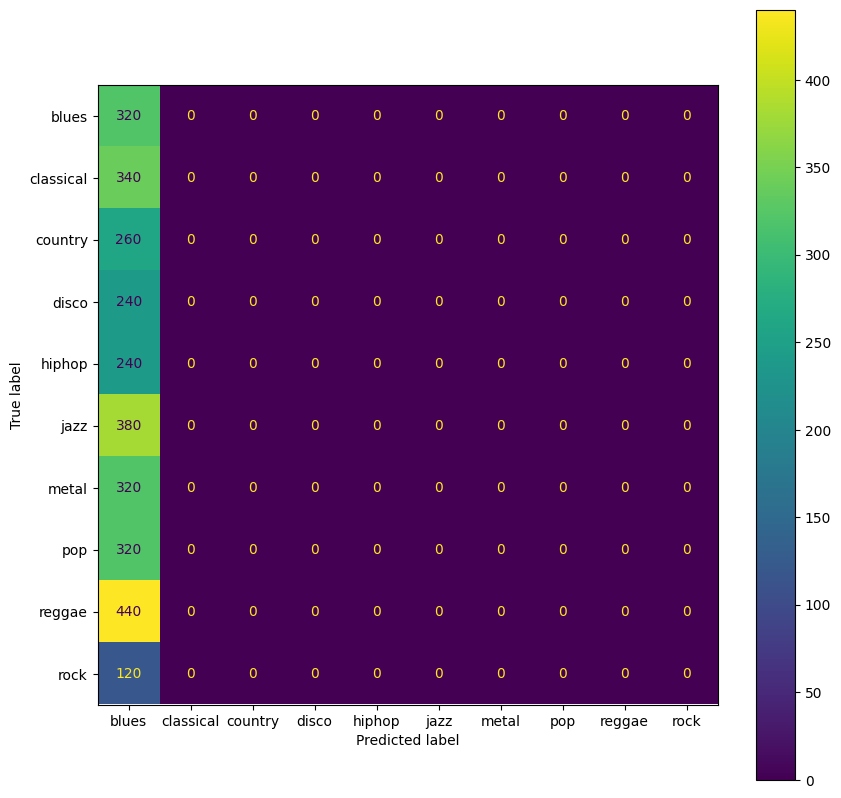



Testing confusion matrix plot:


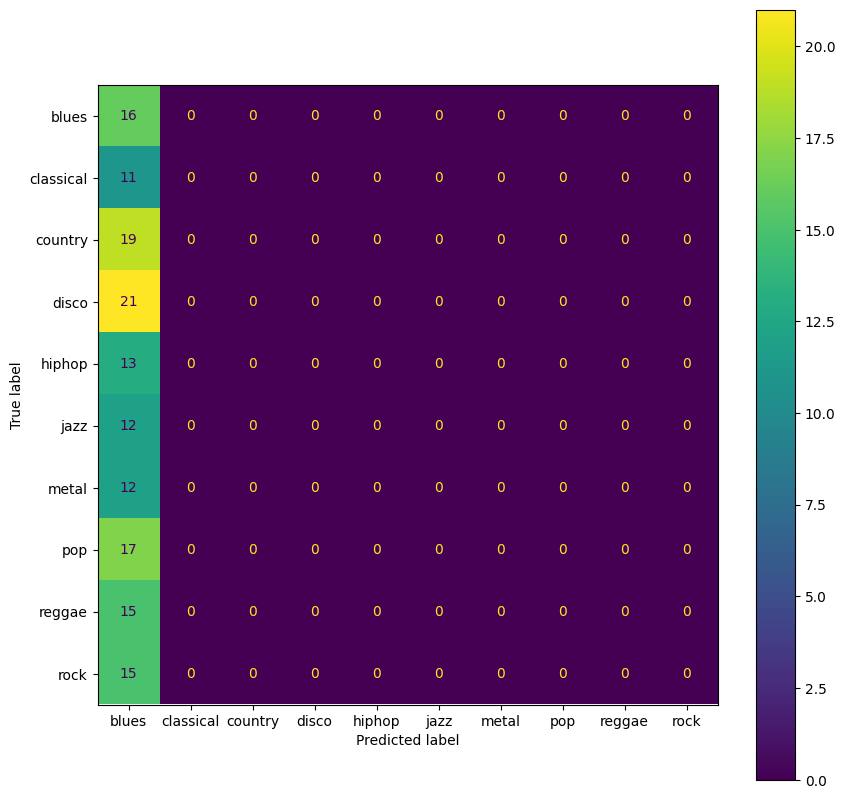

Training classification report:
              precision    recall  f1-score   support

       blues       0.10      0.90      0.18     43520
   classical       0.08      0.01      0.02     46080
     country       0.11      0.01      0.01     43520
       disco       0.11      0.01      0.02     42880
      hiphop       0.10      0.01      0.01     48000
        jazz       0.09      0.01      0.02     43520
       metal       0.09      0.01      0.02     46080
         pop       0.09      0.02      0.03     42880
      reggae       0.10      0.02      0.04     40320
        rock       0.11      0.02      0.04     50560

    accuracy                           0.10    447360
   macro avg       0.10      0.10      0.04    447360
weighted avg       0.10      0.10      0.04    447360



Validation classification report:
              precision    recall  f1-score   support

       blues       0.11      1.00      0.19       320
   classical       0.00      0.00      0.00       340
     count

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

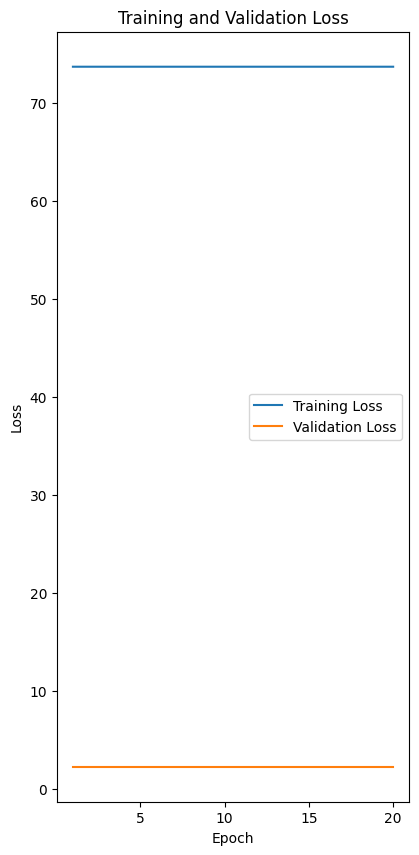

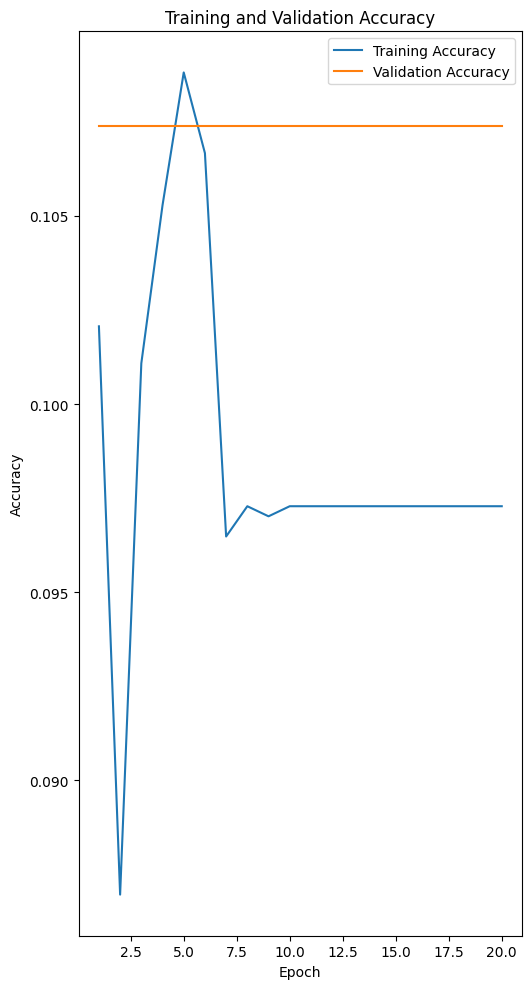

In [3]:
# Create model using class
class FirstModel(nn.Module):
  def __init__(self):
    super().__init__()

    # First set of layers
    self.firstConv2d = nn.Conv2d(in_channels = 3, out_channels = 3, kernel_size = 3)
    self.firstPooling = nn.MaxPool2d(kernel_size = 3)
    self.firstNormalization = nn.BatchNorm2d(3)
    self.firstReLU = nn.ReLU()

    # Second set of layers
    self.secondConv2d = nn.Conv2d(in_channels = 3, out_channels = 2, kernel_size = 3)
    self.secondPooling = nn.MaxPool2d(kernel_size = 3)
    self.secondNormalization = nn.BatchNorm2d(2)
    self.secondReLU = nn.ReLU()

    # Third set of layers
    self.thirdConv2d = nn.Conv2d(in_channels = 2, out_channels = 1, kernel_size = 2)
    self.thirdPooling = nn.MaxPool2d(kernel_size = 3)
    self.thirdNormalization = nn.BatchNorm2d(1)
    self.thirdReLU = nn.ReLU()

    # Final set of layers
    self.finalLinear = nn.Linear(15, 1)
    self.fourthNormalization = nn.BatchNorm2d(1)
    self.fourthReLU = nn.ReLU()
    self.makingSoftmax = nn.Softmax(0)

  # Forward function
  def forward(self, data):

    # First convolution layer
    data = self.firstConv2d(data)

    # First pooling layer
    data = self.firstPooling(data)

    # First normalization layer
    data = self.firstNormalization(data)

    # First ReLU of pooling layer
    data = self.firstReLU(data)

    # Second convolution layer
    data = self.secondConv2d(data)

    # Second pooling layer
    data = self.secondPooling(data)

    # Second normalization layer
    data = self.secondNormalization(data)

    # Second ReLU of pooling layer
    data = self.secondReLU(data)

    # Third convolution layer
    data = self.thirdConv2d(data)

    # Third pooling layer
    data = self.thirdPooling(data)

    # Third normalization layer
    data = self.thirdNormalization(data)

    # Third ReLU of pooling layer
    data = self.thirdReLU(data)

    # Final linear layer
    data = self.finalLinear(data)

    # Fourth normalization layer
    data = self.fourthNormalization(data)

    # Fourth ReLU of final linear layer
    data = self.fourthReLU(data)

    # Softmax of sigmoid
    data = self.makingSoftmax(data)

    # Reshaping data into 2d tensor and returning it
    data = data.reshape((data.shape[0] * data.shape[1], data.shape[2] * data.shape[3]))
    return data

# Set learning rate and weight decay
learningRateValue = 1
weightDecay = 1

# Set up model and put it on device
firstModel = FirstModel()
firstModel.to(device)

# Train model
firstModel.train()

# Cross entropy loss and Adam optimization
lossType = nn.CrossEntropyLoss()
optimizerType = optim.Adam(firstModel.parameters(), lr = learningRateValue, weight_decay = weightDecay)

# Do the training with a given number of epochs as well as create lists to hold training and validation losses and accuracies
print('Train')
numberOfEpochs = 20
trainingLossList = []
trainingAccuracyList = []
validationLossList = []
validationAccuracyList = []
allLabelsTrain = []
allLabelsValidation = []
allLabelsTest = []
allIndividualPredictionsTrain = []
allIndividualPredictionsValidation = []
allIndividualPredictionsTest = []
for epochNumber in range(numberOfEpochs):

  # Keep track of number of samples, number of correct predictions, and loss
  numberOfSamplesTrain = 0
  numberOfCorrectPredictionsTrain = 0
  combinedLossTrain = 0.0

  # Go through each training batch
  for imagesTrain, labelsTrain in dataLoaderTrain:

    # Get number of augmentations from the second dimension of the image batch, reshape the batch to be 4 dimensional instead of 5, and get the correct number of labels while putting all on GPU
    numberOfAugmentationsTrain = imagesTrain.shape[1]
    imagesTrain = imagesTrain.reshape((imagesTrain.shape[0] * imagesTrain.shape[1], imagesTrain.shape[2], imagesTrain.shape[3], imagesTrain.shape[4]))
    labelsTrain = torch.repeat_interleave(labelsTrain, numberOfAugmentationsTrain)
    allLabelsTrain.extend(list(labelsTrain))
    imagesTrain = imagesTrain.to(device)
    labelsTrain = labelsTrain.to(device)

    # Reset the gradients for each training run and get the model object
    optimizerType.zero_grad()
    modelResultTrain = firstModel(imagesTrain)

    # Calculate loss, conduct backwards propogation, take a step in the negative gradient direction, and add to the total loss
    finalLossTrain = lossType(modelResultTrain, labelsTrain)
    finalLossTrain.backward()
    optimizerType.step()
    combinedLossTrain = combinedLossTrain + finalLossTrain.item() * imagesTrain.shape[0]

    # Getting the training predictions, adding to the number of correct predictions, and adding to the total number of samples
    _, individualPredictionsTrain = torch.max(modelResultTrain, dim = 1)
    allIndividualPredictionsTrain.extend(list(individualPredictionsTrain))
    currentPredictionIndicatorTrain = (individualPredictionsTrain == labelsTrain)
    numberOfCorrectPredictionsTrain = numberOfCorrectPredictionsTrain + currentPredictionIndicatorTrain.sum().item()
    numberOfSamplesTrain = numberOfSamplesTrain + labelsTrain.shape[0]

  # Calculate the current epoch loss and the current epoch accuracy
  currentEpochLossTrain = combinedLossTrain / len(trainDataset)
  trainingLossList.append(currentEpochLossTrain)
  currentEpochAccuracyTrain = numberOfCorrectPredictionsTrain / numberOfSamplesTrain
  trainingAccuracyList.append(currentEpochAccuracyTrain)
  print('for training epoch number ', epochNumber + 1, ', the loss is ', currentEpochLossTrain, ' and the accuracy is ', currentEpochAccuracyTrain)

  # Do validation
  firstModel.eval()

  # Keep track of number of samples, number of correct predictions, and loss
  combinedLossValidation = 0.0
  numberOfCorrectPredictionsValidation = 0
  numberOfSamplesValidation = 0

  # Don't keep track of the gradients
  with torch.no_grad():

    # Go through each validation batch
    for imagesValidation, labelsValidation in dataLoaderValidation:

      # Get number of augmentations from the second dimension of the image batch, reshape the batch to be 4 dimensional instead of 5, and get the correct number of labels while putting all on GPU
      numberOfAugmentationsValidation = imagesValidation.shape[1]
      imagesValidation = imagesValidation.reshape((imagesValidation.shape[0] * imagesValidation.shape[1], imagesValidation.shape[2], imagesValidation.shape[3], imagesValidation.shape[4]))
      labelsValidation = torch.repeat_interleave(labelsValidation, numberOfAugmentationsValidation)
      allLabelsValidation.extend(labelsValidation)
      imagesValidation = imagesValidation.to(device)
      labelsValidation = labelsValidation.to(device)

      # Get the model object
      modelResultValidation = firstModel(imagesValidation)

      # Calculate loss and add to the total loss
      finalLossValidation = lossType(modelResultValidation, labelsValidation)
      combinedLossValidation = combinedLossValidation + finalLossValidation.item() * imagesValidation.shape[0]

      # Getting the validation predictions, adding to the number of correct predictions, and adding to the total number of samples
      _, individualPredictionsValidation = torch.max(modelResultValidation, dim = 1)
      allIndividualPredictionsValidation.extend(list(individualPredictionsValidation))
      currentPredictionIndicatorValidation = (individualPredictionsValidation == labelsValidation)
      numberOfCorrectPredictionsValidation = numberOfCorrectPredictionsValidation + currentPredictionIndicatorValidation.sum().item()
      numberOfSamplesValidation = numberOfSamplesValidation + labelsValidation.shape[0]

  # Calculate the current epoch loss and the current epoch accuracy
  currentEpochLossValidation = combinedLossValidation / len(validationDataset)
  validationLossList.append(currentEpochLossValidation)
  currentEpochAccuracyValidation = numberOfCorrectPredictionsValidation / numberOfSamplesValidation
  validationAccuracyList.append(currentEpochAccuracyValidation)
  print('for epoch number ', epochNumber + 1, ', the loss is ', currentEpochLossValidation, ' and the accuracy is ', currentEpochAccuracyValidation)

  # Put model back into training
  firstModel.train()

# Finished training
print('Train done')

# Do testing
firstModel.eval()

# Keep track of number of samples, number of correct predictions, and loss
combinedLossTest = 0.0
numberOfCorrectPredictionsTest = 0
numberOfSamplesTest = 0

# Don't keep track of the gradients
with torch.no_grad():

  # Go through each test batch
  for imagesTest, labelsTest in dataLoaderTest:

    # Get number of augmentations from the second dimension of the image batch, reshape the batch to be 4 dimensional instead of 5, and get the correct number of labels while putting all on GPU
    numberOfAugmentationsTest = imagesTest.shape[1]
    imagesTest = imagesTest.reshape((imagesTest.shape[0] * imagesTest.shape[1], imagesTest.shape[2], imagesTest.shape[3], imagesTest.shape[4]))
    labelsTest = torch.repeat_interleave(labelsTest, numberOfAugmentationsTest)
    allLabelsTest.extend(labelsTest)
    imagesTest = imagesTest.to(device)
    labelsTest = labelsTest.to(device)

    # Get the model object
    modelResultTest = firstModel(imagesTest)

    # Calculate loss and add to the total loss
    finalLossTest = lossType(modelResultTest, labelsTest)
    combinedLossTest = combinedLossTest + finalLossTest.item() * imagesTest.shape[0]

    # Getting the testing predictions, adding to the number of correct predictions, and adding to the total number of samples
    _, individualPredictionsTest = torch.max(modelResultTest, dim = 1)
    allIndividualPredictionsTest.extend(list(individualPredictionsTest))
    currentPredictionIndicatorTest = (individualPredictionsTest == labelsTest)
    numberOfCorrectPredictionsTest = numberOfCorrectPredictionsTest + currentPredictionIndicatorTest.sum().item()
    numberOfSamplesTest = numberOfSamplesTest + labelsTest.shape[0]

# Calculate the current test loss and the current test accuracy
currentEpochLossTest = combinedLossTest / len(testDataset)
currentEpochAccuracyTest = numberOfCorrectPredictionsTest / numberOfSamplesTest
print('for testing, the loss is ', currentEpochLossTest, ' and the accuracy is ', currentEpochAccuracyTest)

# Train
newAllLabelsTrain = []
for oneTrainLabel in allLabelsTrain:
  newAllLabelsTrain.append(classDictionary[oneTrainLabel.item()])
newAllIndividualPredictionsTrain = []
for oneTrainLabel2 in allIndividualPredictionsTrain:
  newAllIndividualPredictionsTrain.append(classDictionary[oneTrainLabel2.item()])
# print('LabelsTrain:', '\n', labelsTrain, '\n', 'has a length of ', len(labelsTrain))
# print('NewAllLabelsTrain:', '\n', newAllLabelsTrain, '\n', 'has a length of ', len(newAllLabelsTrain))
# print('NewIndividualPredictionsTrain:', '\n', newAllIndividualPredictionsTrain, '\n', 'has a length of ', len(newAllIndividualPredictionsTrain))

# Validation
newAllLabelsValidation = []
for oneValidationLabel in allLabelsValidation:
  newAllLabelsValidation.append(classDictionary[oneValidationLabel.item()])
newAllIndividualPredictionsValidation = []
for oneValidationLabel2 in allIndividualPredictionsValidation:
  newAllIndividualPredictionsValidation.append(classDictionary[oneValidationLabel2.item()])
# print('LabelsValidation:', '\n', labelsValidation, '\n', 'has a length of ', len(labelsValidation))
# print('NewAllLabelsValidation:', '\n', newAllLabelsValidation, '\n', 'has a length of ', len(newAllLabelsValidation))
# print('NewIndividualPredictionsValidation:', '\n', newAllIndividualPredictionsValidation, '\n', 'has a length of ', len(newAllIndividualPredictionsValidation))

# Test
newAllLabelsTest = []
for oneTestLabel in allLabelsTest:
  newAllLabelsTest.append(classDictionary[oneTestLabel.item()])
newAllIndividualPredictionsTest = []
for oneTestLabel2 in allIndividualPredictionsTest:
  newAllIndividualPredictionsTest.append(classDictionary[oneTestLabel2.item()])
# print('LabelsTest:', '\n', labelsTest, '\n', 'has a length of ', len(labelsTest))
# print('NewAllLabelsTest:', '\n', newAllLabelsTest, '\n', 'has a length of ', len(newAllLabelsTest))
# print('NewIndividualPredictionsTest:', '\n', newAllIndividualPredictionsTest, '\n', 'has a length of ', len(newAllIndividualPredictionsTest))

# Adjusting figure size
figurePlot, figureAxis = plt.subplots(figsize = (10, 10))
plt.rcParams["figure.figsize"] = (10, 10)

# Confusion matrix for train, validation, and test
confusionMatrixTrain = confusion_matrix(newAllLabelsTrain, newAllIndividualPredictionsTrain)
confusionMatrixValidation = confusion_matrix(newAllLabelsValidation, newAllIndividualPredictionsValidation)
confusionMatrixTest = confusion_matrix(newAllLabelsTest, newAllIndividualPredictionsTest)
print('\n')
print("Training confusion matrix:")
print(confusionMatrixTrain)
print('\n')
print("Validation confusion matrix:")
print(confusionMatrixValidation)
print('\n')
print("Testing confusion matrix:")
print(confusionMatrixTest)
print('\n')
print("Training confusion matrix plot:")
ConfusionMatrixDisplay.from_predictions(newAllLabelsTrain, newAllIndividualPredictionsTrain, ax = figureAxis)
plt.savefig("drive/MyDrive/CS7643Plots/ConfusionMatrixTrainEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".png")
plt.show()
print('\n')
print("Validation confusion matrix plot:")
figurePlot, figureAxis = plt.subplots(figsize = (10, 10))
ConfusionMatrixDisplay.from_predictions(newAllLabelsValidation, newAllIndividualPredictionsValidation, ax = figureAxis)
plt.savefig("drive/MyDrive/CS7643Plots/ConfusionMatrixValidationEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".png")
plt.show()
print('\n')
print("Testing confusion matrix plot:")
figurePlot, figureAxis = plt.subplots(figsize = (10, 10))
ConfusionMatrixDisplay.from_predictions(newAllLabelsTest, newAllIndividualPredictionsTest, ax = figureAxis)
plt.savefig("drive/MyDrive/CS7643Plots/ConfusionMatrixTestEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".png")
plt.show()

# Classification reports
print("Training classification report:")
print(classification_report(newAllLabelsTrain, newAllIndividualPredictionsTrain))
trainingClassificationReportDictionary = classification_report(newAllLabelsTrain, newAllIndividualPredictionsTrain, output_dict = True)
trainingClassificationReportTable = pd.DataFrame(trainingClassificationReportDictionary)
trainingClassificationReportTable.to_csv("drive/MyDrive/CS7643Plots/TrainingClassificationReportEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".csv")
print('\n')
print("Validation classification report:")
print(classification_report(newAllLabelsValidation, newAllIndividualPredictionsValidation))
validationClassificationReportDictionary = classification_report(newAllLabelsValidation, newAllIndividualPredictionsValidation, output_dict = True)
validationClassificationReportTable = pd.DataFrame(validationClassificationReportDictionary)
validationClassificationReportTable.to_csv("drive/MyDrive/CS7643Plots/ValidationClassificationReportEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".csv")
print('\n')
print("Testing classification report:")
print(classification_report(newAllLabelsTest, newAllIndividualPredictionsTest))
testingClassificationReportDictionary = classification_report(newAllLabelsTest, newAllIndividualPredictionsTest, output_dict = True)
testingClassificationReportTable = pd.DataFrame(testingClassificationReportDictionary)
testingClassificationReportTable.to_csv("drive/MyDrive/CS7643Plots/TestingClassificationReportEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".csv")

# Final training and validation loss and accuracy
print('the final training loss is ', currentEpochLossTrain, ' and the final training accuracy is ', currentEpochAccuracyTrain)
print('the final validation loss is ', currentEpochLossValidation, ' and the final validation accuracy is ', currentEpochAccuracyValidation)

# Dataset to hold loss and accuracy
lossAndAccuracyDataFrame = pd.DataFrame({
    'Epoch': range(1, numberOfEpochs + 1),
    'Training Loss': trainingLossList,
    'Validation Loss': validationLossList,
    'Training Accuracy': trainingAccuracyList,
    'Validation Accuracy': validationAccuracyList
})

# Plotting Loss
plt.subplot(1, 2, 1)
sns.lineplot(x = 'Epoch', y = 'Training Loss', data = lossAndAccuracyDataFrame, label = 'Training Loss')
sns.lineplot(x = 'Epoch', y = 'Validation Loss', data = lossAndAccuracyDataFrame, label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show and save figure
plt.savefig("drive/MyDrive/CS7643Plots/LossEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".png")
plt.show()

# Plotting Accuracy
plt.subplot(1, 2, 2)
sns.lineplot(x = 'Epoch', y = 'Training Accuracy', data = lossAndAccuracyDataFrame, label = 'Training Accuracy')
sns.lineplot(x = 'Epoch', y = 'Validation Accuracy', data = lossAndAccuracyDataFrame, label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Tighten layout
plt.tight_layout()

# Show and save figure
plt.savefig("drive/MyDrive/CS7643Plots/AccuracyEpochs" + str(numberOfEpochs) + "LearningRate" + str(learningRateValue) + "WeightDecay" + str(weightDecay) + "BatchSize" + str(batchSize) + ".png")
plt.show()

# Unassign GPU
from google.colab import runtime
runtime.unassign()

In [4]:
# Unassign GPU
from google.colab import runtime
runtime.unassign()